In [1]:
import json
import os
from pathlib import Path
import requests
import tiktoken
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [3]:
data[1], data[100], data[1000]

({'instruction': 'Edit the following sentence for grammar.',
  'input': 'He go to the park every day.',
  'output': 'He goes to the park every day.'},
 {'instruction': 'Name a synonym for "happiness."',
  'input': '',
  'output': 'A synonym for "happiness" is "joy."'},
 {'instruction': 'Name three forms of water.',
  'input': '',
  'output': 'The three forms of water are solid (ice), liquid (water), and gas (steam).'})

In [4]:
# Partitioning the dataset
n1 = int(len(data) * 0.85)
n2 = int(len(data) * 0.95)

train_data = data[:n1]  # 85%
test_data = data[n1:n2] # 10%
val_data = data[n2:]    # 5%

In [5]:
def data_alpaca_format(entry, with_response=True):
  return (
      f"Below is an instruction that describes a task. "
      f"Write a response that appropriately completes the request."
      f"\n\n### Instruction:\n{entry['instruction']}"
      f"{'\n\n### Input:\n'+entry['input'] if entry['input'] else ''}"
      f"{'\n\n### Response:\n'+entry['output'] if with_response else ''}"
  )

In [6]:
print(data_alpaca_format(data[1]), end="\n\n")
print(data_alpaca_format(data[100]), end="\n\n")
print(data_alpaca_format(data[1000]), end='\n\n')

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Edit the following sentence for grammar.

### Input:
He go to the park every day.

### Response:
He goes to the park every day.

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name a synonym for "happiness."

### Response:
A synonym for "happiness" is "joy."

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name three forms of water.

### Response:
The three forms of water are solid (ice), liquid (water), and gas (steam).



### Defining Dataset and Dataloader

In [7]:
class InstructDataset(Dataset):
  def __init__(self, data, format_func, tokenizer):
    self.formatted_texts = [format_func(entry) for entry in data]
    self.encoded_texts = [tokenizer.encode(text) for text in self.formatted_texts]

  def __getitem__(self, idx):
    return self.encoded_texts[idx]

  def __len__(self):
    return len(self.encoded_texts)


In [8]:
tokenizer = tiktoken.get_encoding('gpt2')
train_ds = InstructDataset(train_data, data_alpaca_format, tokenizer)
val_ds = InstructDataset(val_data, data_alpaca_format, tokenizer)
test_ds = InstructDataset(test_data, data_alpaca_format, tokenizer)
print(f"Train: {len(train_ds)}\nVal: {len(val_ds)}\nTest: {len(test_ds)}")

Train: 935
Val: 55
Test: 110


## Defining a custom collate function
What collate_fn does

When you use a DataLoader, it:

- Calls __getitem__() multiple times to get samples
- Passes the list of samples to collate_fn
- collate_fn combines them into a batch

```
def collate_fn(batch):
  ...
```

In [10]:
def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100, device='cpu', allowed_max_length=None):

  max_length = max([len(item) for item in batch])
  #print(f"Max length: {max_length}")
  inputs, targets = [], []
  for initial_input in batch:
    #print(f"Initial Length {len(initial_input)}")
    #print(f"I: {initial_input}")
    input = initial_input + [pad_token_id]
    #print(f"P1: {input}")
    input += [pad_token_id] * (max_length - len(initial_input))
    input = torch.tensor(input)
    #print(f"P2: {input.shape} \n{input}")
    #print(f"Final length : {len(input)}")
    target = input[1:].clone()
    input = input[:-1]
    mask = target == pad_token_id
    pad_indices = mask.nonzero().squeeze(1)
    #print(pad_indices.shape, pad_indices)
    if pad_indices.numel() > 1:
      target[pad_indices[1:]] = ignore_index

    if allowed_max_length is not None:
      input = input[:allowed_max_length]
      target = target[:allowed_max_length]

    inputs.append(input)
    targets.append(target)

  input_batch = torch.stack(inputs).to(device)
  target_batch = torch.stack(targets).to(device)

  return input_batch, target_batch

test_batch = [train_ds[0], train_ds[50], train_ds[100]]
i,t = custom_collate_fn(test_batch)
i.shape, t.shape, i[1], t[1]

(torch.Size([3, 74]),
 torch.Size([3, 74]),
 tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
           257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
         21017, 46486,    25,   198, 33234,  1958,   262,  3376, 24993,   286,
           262,  1708,  1573,    13,   198,   198, 21017, 23412,    25,   198,
            46,    66, 11857,   198,   198, 21017, 18261,    25,   198,   464,
          3376, 24993,   318,   705, 29223,  4247,  2637, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256]),
 tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
          2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
         46486,    25,   198, 33234,  1958,   262,  3376, 24993,   286,   262,
          1708,  1573,    13,   198,   198, 21017, 23412,    25,   198,    46,
            66, 11857,   198,   198, 21017, 1826

In [11]:
from functools import partial

device = 'cuda' if torch.cuda.is_available() else 'cpu'

instruct_dataset_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024

)

batch_size = 8
train_dataloader = DataLoader(
    train_ds,
    batch_size=batch_size,
    collate_fn=instruct_dataset_collate_fn,
    shuffle=True,
    num_workers=0,
    drop_last=True
)
val_dataloader = DataLoader(
    val_ds,
    batch_size=batch_size,
    collate_fn=instruct_dataset_collate_fn,
    num_workers=0,
    shuffle=False,
    drop_last=False
)
test_dataloader = DataLoader(
    test_ds,
    batch_size=batch_size,
    collate_fn=instruct_dataset_collate_fn,
    num_workers=0,
    shuffle=False,
    drop_last=False
)


In [12]:
for x,y in train_dataloader:
  break

x.shape, y.shape

(torch.Size([8, 69]), torch.Size([8, 69]))

In [13]:
## Toy example to understand ignore_index

logits_1 = torch.tensor([
    [1, -1.5],
    [1.5, 0.5]
])
targets_1 = torch.tensor([0, 1])
loss_1 = F.cross_entropy(logits_1, targets_1)
print(loss_1)

logits_2 = torch.tensor([
    [1, -1.5],
    [1.5, 0.5],
    [0.3, 1.7]
])
targets_2 = torch.tensor([0, 1, 1])
loss_2 = F.cross_entropy(logits_2, targets_2)
print(loss_2)

targets_3 = torch.tensor([0, 1, -100])
loss_3 = F.cross_entropy(logits_2, targets_3)
print(loss_3)

loss_3 == loss_1

tensor(0.6961)
tensor(0.5375)
tensor(0.6961)


tensor(True)

### Loading model from pretrained OpenAI weights

In [14]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim, eps=1e-5):
    super().__init__()
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))
    self.eps = eps

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False) # divide by n here to be consistent with what was used in GPT2
    x = (x-mean)/torch.sqrt(var + self.eps)
    x = x*self.scale + self.shift
    return x


class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    x = 0.5 * x * (1 + torch.tanh(
          torch.sqrt(torch.tensor(2)/torch.pi) * (x + 0.044715*(x**3))
        ))
    return x


class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    emb_dim = cfg["emb_dim"]
    self.layers = nn.Sequential(
        nn.Linear(emb_dim, 4*emb_dim),
        GELU(),
        nn.Linear(4*emb_dim, emb_dim)
    )

  def forward(self, x):
    return self.layers(x)


class MultiHeadAttention(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    d_in, d_out = cfg["emb_dim"], cfg["emb_dim"]
    context_length = cfg["context_length"]
    dropout = cfg["drop_rate"]
    num_heads = cfg["n_heads"]
    qkv_bias = cfg["qkv_bias"]

    assert(d_out % num_heads == 0)

    self.head_dim = d_out // num_heads
    self.num_heads = num_heads

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )
    self.projection = nn.Linear(d_out, d_out)

  def forward(self, x):
    # x -> [B, T, d_in]
    B, T, d_in = x.shape

    queries = self.W_query(x)
    keys = self.W_key(x)
    values = self.W_value(x)

    queries = queries.view(B, T, self.num_heads, self.head_dim) # [B, T, NH, HD]
    queries = queries.transpose(1, 2) # [B, NH, T, HD]
    keys = keys.view(B, T, self.num_heads, self.head_dim) # [B, T, NH, HD]
    keys = keys.transpose(1, 2) # [B, NH, T, HD]
    values = values.view(B, T, self.num_heads, self.head_dim)
    values = values.transpose(1, 2) # [B, NH, T, HD]

    attn_scores = queries @ keys.transpose(2, 3) # [B, NH, T, T]
    attn_scores.masked_fill_(self.mask.bool()[:T,:T], -torch.inf)
    attn_weights = torch.softmax(attn_scores/self.head_dim**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vecs = attn_weights @ values # [B, NH, T, HD]
    context_vecs = context_vecs.transpose(1,2).reshape(B, T, -1)
    # Reshape instead of view because view needs contiguous
    # Alternative context_vecs.contiguous().view(B, T, -1)
    context_vecs = self.projection(context_vecs) # [B, T, d_out]
    return context_vecs



class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.attn_block = MultiHeadAttention(cfg)
    self.ffwd = FeedForward(cfg)
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.layer_norm1 = LayerNorm(cfg["emb_dim"])
    self.layer_norm2 = LayerNorm(cfg["emb_dim"])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.attn_block(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffwd(x)
    x = self.dropout(x)
    x = x + shortcut

    return x


class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_embedding = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_embedding = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.layer_norm = LayerNorm(cfg["emb_dim"])
    self.transformer_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False) # Weight reused here in Open AI GPT2

  def forward(self, x):
    # x.shape [B, T]
    B, T = x.shape
    token_embd = self.token_embedding(x) # [B, T, E]  E -> emb_dim
    pos_embd = self.pos_embedding(torch.arange(0, T).to(device)) # [T, E]
    x = token_embd + pos_embd # [T, E] broadcasted to [B, T, E] and then add
    x = self.dropout(x)
    x = self.transformer_blocks(x)
    x = self.layer_norm(x)
    x = self.out_head(x)
    return x


In [15]:
import urllib.request

url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch05/01_main-chapter-code/gpt_download.py"
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)


from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

def assign(left, right):

  if left.shape != right.shape:
    raise ValueError(f"Shape mismatch {left.shape} {right.shape}")

  return torch.nn.Parameter(torch.tensor(right))

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 89.3kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.75MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 192kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:48<00:00, 10.2MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 10.4MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.96MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.93MiB/s]


In [31]:
GPT_CONFIG_124M = {
  "vocab_size": 50257,
  "context_length": 1024,
  "emb_dim": 768,
  "n_heads": 12,
  "n_layers": 12,
  "drop_rate": 0.0,
  "qkv_bias": True
}

import numpy as np

def load_openai_weights(model, params):
  model.token_embedding.weight = assign(model.token_embedding.weight, params["wte"])
  model.pos_embedding.weight = assign(model.pos_embedding.weight, params["wpe"])

  for idx in range(len(model.transformer_blocks)):

    # Layer Norm 1
    model.transformer_blocks[idx].layer_norm1.scale = assign(
        model.transformer_blocks[idx].layer_norm1.scale,
        params["blocks"][idx]["ln_1"]["g"]
    )
    model.transformer_blocks[idx].layer_norm1.shift = assign(
        model.transformer_blocks[idx].layer_norm1.shift,
        params["blocks"][idx]["ln_1"]["b"]
    )

    # Attention
    W_Q, W_K, W_V = np.split(params["blocks"][idx]["attn"]["c_attn"]["w"], 3, axis=-1)
    B_Q, B_K, B_V = np.split(params["blocks"][idx]["attn"]["c_attn"]["b"], 3, axis=-1)

    model.transformer_blocks[idx].attn_block.W_query.weight = assign(
        model.transformer_blocks[idx].attn_block.W_query.weight,
        W_Q.T
    )
    model.transformer_blocks[idx].attn_block.W_query.bias = assign(
        model.transformer_blocks[idx].attn_block.W_query.bias,
        B_Q.T
    )
    model.transformer_blocks[idx].attn_block.W_key.weight = assign(
        model.transformer_blocks[idx].attn_block.W_key.weight,
        W_K.T
    )
    model.transformer_blocks[idx].attn_block.W_key.bias = assign(
        model.transformer_blocks[idx].attn_block.W_key.bias,
        B_K
    )
    model.transformer_blocks[idx].attn_block.W_value.weight = assign(
        model.transformer_blocks[idx].attn_block.W_value.weight,
        W_V.T
    )
    model.transformer_blocks[idx].attn_block.W_value.bias = assign(
        model.transformer_blocks[idx].attn_block.W_value.bias,
        B_V
    )

    model.transformer_blocks[idx].attn_block.projection.weight = assign(
        model.transformer_blocks[idx].attn_block.projection.weight,
        params["blocks"][idx]["attn"]["c_proj"]["w"].T
    )
    model.transformer_blocks[idx].attn_block.projection.bias = assign(
        model.transformer_blocks[idx].attn_block.projection.bias,
        params["blocks"][idx]["attn"]["c_proj"]["b"]
    )

    # Layer Norm 2
    model.transformer_blocks[idx].layer_norm2.scale = assign(
        model.transformer_blocks[idx].layer_norm2.scale,
        params["blocks"][idx]["ln_2"]["g"]
    )
    model.transformer_blocks[idx].layer_norm2.shift = assign(
        model.transformer_blocks[idx].layer_norm2.shift,
        params["blocks"][idx]["ln_2"]["b"]
    )

    # Feed Forward
    model.transformer_blocks[idx].ffwd.layers[0].weight = assign(
        model.transformer_blocks[idx].ffwd.layers[0].weight,
        params["blocks"][idx]["mlp"]["c_fc"]["w"].T
    )
    model.transformer_blocks[idx].ffwd.layers[0].bias = assign(
        model.transformer_blocks[idx].ffwd.layers[0].bias,
        params["blocks"][idx]["mlp"]["c_fc"]["b"]
    )
    model.transformer_blocks[idx].ffwd.layers[2].weight = assign(
        model.transformer_blocks[idx].ffwd.layers[2].weight,
        params["blocks"][idx]["mlp"]["c_proj"]["w"].T
    )
    model.transformer_blocks[idx].ffwd.layers[2].bias = assign(
        model.transformer_blocks[idx].ffwd.layers[2].bias,
        params["blocks"][idx]["mlp"]["c_proj"]["b"]
    )


  # Final Layer Norm
  model.layer_norm.scale = assign(
      model.layer_norm.scale,
      params["g"]
  )
  model.layer_norm.shift = assign(
      model.layer_norm.shift,
      params["b"]
  )

  # Out head
  model.out_head.weight = assign(
      model.out_head.weight,
      params["wte"] # Reuses weights from token embedding layer
  )

In [32]:
model = GPTModel(GPT_CONFIG_124M)
load_openai_weights(model, params)
model.to(device)
model.eval()

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (pos_embedding): Embedding(1024, 768)
  (layer_norm): LayerNorm()
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attn_block): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (projection): Linear(in_features=768, out_features=768, bias=True)
      )
      (ffwd): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout): Dropout(p=0.0, inplace=False)
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
    )
    (1): TransformerBlock(
      (attn_block): MultiHeadAttention(
        (

In [33]:
def text_to_token_ids(text, tokenizer):
  token_ids = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
  token_ids = torch.tensor(token_ids).unsqueeze(0)
  return token_ids

def token_ids_to_text(token_ids, tokenizer):
  text = tokenizer.decode(token_ids.squeeze(0).tolist())
  return text

def generate_text_simple(input_batch, model, context_length, device, max_tokens=50, eos_token_id=50256):
  for _ in range(max_tokens):
    input_batch = input_batch[:, -context_length:]
    input_batch = input_batch.to(device)
    model = model.to(device)
    with torch.no_grad():
      logits = model(input_batch)
    probs = torch.softmax(logits[:,-1,:], dim=-1)
    next = torch.argmax(probs, dim=-1, keepdim=True)
    if next.item() == eos_token_id:
      break
    input_batch = torch.cat([input_batch, next], dim=1)

  return input_batch

In [19]:
print(data_alpaca_format(val_data[0], with_response=False))
print(data_alpaca_format(val_data[0]))

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:
The meal is cooked by the chef every day.


In [34]:
torch.manual_seed(123)
sample_instruction = data_alpaca_format(
    val_data[0],
    with_response=False
)
print(sample_instruction)

token_ids = generate_text_simple(
    text_to_token_ids(sample_instruction, tokenizer),
    model,
    1024,
    device,
    max_tokens=100
)
print(token_ids_to_text(token_ids, tokenizer))

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Instruction


In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device) # [B, T]
  logits = model(input_batch) # [B, T, vocab_size]
  logits_flatten = logits.flatten(0,1) # [B*T, vocab_size]
  targets_flatten = target_batch.flatten() # [B*T]
  loss = F.cross_entropy(logits_flatten, targets_flatten)
  return loss

def calc_loss_dataloader(dataloader, model, device, num_batches=None):
  """
  Calculates avg loss over entire dataset unless num_batches is defined.
  """

  if len(dataloader) == 0:
    return float("nan")

  total_batches = None
  total_loss = 0

  if num_batches is None:
    total_batches = len(dataloader)
  else:
    total_batches = min(num_batches, len(dataloader))

  for i, (x,y) in enumerate(dataloader):
    if i < total_batches:
      loss = calc_loss_batch(x, y, model, device)
      total_loss += loss.item()
    else:
      break

  total_loss /= total_batches
  return total_loss

In [ ]:
# Calculating loss before training
with torch.no_grad():
  train_loss = calc_loss_dataloader(
      train_dataloader,
      model,
      device,
      num_batches=5
  )
  val_loss = calc_loss_dataloader(
      val_dataloader,
      model,
      device,
      num_batches=5
  )
print(f"Training loss: {train_loss}")
print(f"Val loss: {val_loss}")

Training loss: 4.167138862609863
Val loss: 4.050934791564941


### Training Model

In [ ]:
def generate_print_sample(start_context, tokenizer, model, max_tokens=50):
  model.eval()

  input_batch = text_to_token_ids(start_context, tokenizer)
  context_length = model.pos_embedding.weight.shape[0]

  generated_token_ids = generate_text_simple(
      input_batch,
      model,
      context_length,
      device,
      max_tokens
  )

  print(token_ids_to_text(generated_token_ids, tokenizer))

  model.train()

In [ ]:
def train_gpt(train_dataloader, val_dataloader, optimizer, num_epochs, device,
              eval_freq, eval_iter, start_context, tokenizer):

  # Needed when evaling
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen = 0
  global_step = 0

  for i in range(num_epochs):
    model.train()
    for (x,y) in train_dataloader:
      loss = calc_loss_batch(x, y, model, device)

      optimizer.zero_grad()
      loss.backward()

      optimizer.step()

      global_step += 1
      tokens_seen += x.numel()

      if global_step % eval_freq == 0:
        model.eval()
        with torch.no_grad():
          train_loss = calc_loss_dataloader(train_dataloader, model, device, eval_iter)
          val_loss = calc_loss_dataloader(val_dataloader, model, device, eval_iter)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)

        print(f"Epoch {i} Global step {global_step} train loss {train_loss} val loss {val_loss}")

        model.train()

    generate_print_sample(start_context, tokenizer, model)

  return train_losses, val_losses, track_tokens_seen

In [ ]:
import time
torch.manual_seed(123)

optimizer = torch.optim.AdamW(
    params=model.parameters(),
    lr=0.00005,
    weight_decay=0.1
)
num_epochs = 2

start_context = data_alpaca_format(val_data[0], with_response=False)

start_time = time.time()

train_losses, val_losses, tokens_seen = train_gpt(
    train_dataloader,
    val_dataloader,
    optimizer=optimizer,
    num_epochs=num_epochs,
    device=device,
    eval_freq=5,
    eval_iter=5,
    start_context=start_context,
    tokenizer=tokenizer
)

end_time = time.time()
execution_time = end_time - start_time
print(f"Training time: {execution_time/60: .2f} minutes")

Epoch 0 Global step 5 train loss 1.6629917860031127 val loss 1.7109715461730957
Epoch 0 Global step 10 train loss 1.3209192991256713 val loss 1.1969589471817017
Epoch 0 Global step 15 train loss 1.005265974998474 val loss 1.0859949588775635
Epoch 0 Global step 20 train loss 1.007768940925598 val loss 1.0507777333259583
Epoch 0 Global step 25 train loss 0.9423067331314087 val loss 1.0116685032844543
Epoch 0 Global step 30 train loss 0.8966037511825562 val loss 0.9847774147987366
Epoch 0 Global step 35 train loss 0.9257563591003418 val loss 0.9545971751213074
Epoch 0 Global step 40 train loss 0.864674961566925 val loss 0.9400841236114502
Epoch 0 Global step 45 train loss 0.8313936352729797 val loss 0.9320099472999572
Epoch 0 Global step 50 train loss 0.7586296081542969 val loss 0.9132012844085693
Epoch 0 Global step 55 train loss 0.8449856162071228 val loss 0.8970700860023498
Epoch 0 Global step 60 train loss 0.9084378600120544 val loss 0.8806710720062256
Epoch 0 Global step 65 train los

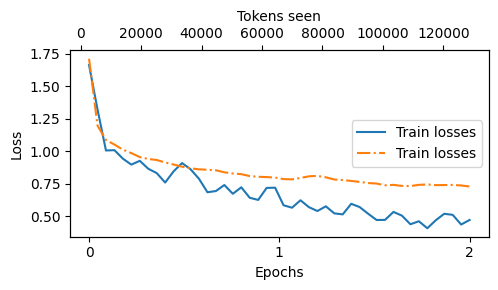

In [ ]:
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt

def plot_losses(epochs_tensor, train_losses, val_losses, tokens_seen):
  fig, ax1 = plt.subplots(figsize=(5, 3))

  ax1.plot(epochs_tensor, train_losses, label='Train losses')
  ax1.plot(epochs_tensor, val_losses, label='Train losses', linestyle='-.')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Loss')
  ax1.legend(loc='center right')
  ax1.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=20)) # No decimal values on x axis

  ax2 = ax1.twiny()
  ax2.plot(tokens_seen, train_losses, label='Train losses', alpha=0)
  ax2.set_xlabel('Tokens seen')

  fig.tight_layout()
  plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, train_losses, val_losses, tokens_seen)

In [ ]:
# Testing on test data

def generate_sample(start_context, tokenizer, model, max_tokens=50):
  model.eval()

  input_batch = text_to_token_ids(start_context, tokenizer)
  context_length = model.pos_embedding.weight.shape[0]

  generated_token_ids = generate_text_simple(
      input_batch,
      model,
      context_length,
      device,
      max_tokens
  )

  model.train()

  return token_ids_to_text(generated_token_ids, tokenizer)

for entry in test_data[:3]:
  input_text = data_alpaca_format(entry, with_response=False)
  resp = generate_sample(input_text, tokenizer, model)

  resp_text = resp[len(input_text):].replace("### Response:","").strip()
  print("=======Input:========\n", input_text)
  print("=======Correct Response:========\n", entry['output'])
  print("=========All model response:=========\n", resp)
  print("==========Model Response:=======\n", resp_text)
  print("============")

=======Input:========
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.
=======Correct Response:========
 The car is as fast as lightning.
=========All model response:=========
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

### Response:
The car is as fast as a horse.
==========Model Response:=======
 The car is as fast as a horse.
=======Input:========
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?
=======Correct Response:========
 The type of cloud typically associated with thunderstorms is cumulonimbus.
=========All model response:=========
 Below is an 

In [ ]:
# Generating responses

from tqdm import tqdm

def save_model_responses(test_data):
  for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = data_alpaca_format(entry, with_response=False)
    resp = generate_sample(input_text, tokenizer, model)
    resp_text = resp[len(input_text):].replace("### Response:","").strip()
    test_data[i]["model_response"] = resp_text

  with open("instruction_model_responses.json", "w") as f:
    json.dump(test_data, f, indent=4)

In [ ]:
save_model_responses(test_data)


100%|██████████| 110/110 [00:44<00:00,  2.48it/s]


In [ ]:
from google.colab import files
files.download('instruction_model_responses.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### EXERCISE 7.4

Parameter efficient fine-tuning with LoRA

- First it helps in adaptation throughout entire attention layers and MLP for new tasks as compared to say final layer finetuning we did earlier
- We can use different weights for different tasks which are only say 1% of total model params
- LoRA matrices are saved independently without modifying the initial pretraining weights.

In [35]:
import math
class LoRALayer(nn.Module):
  def __init__(self, in_dim, out_dim, rank, alpha):
    super().__init__()
    self.A = torch.nn.Parameter(torch.empty(in_dim, rank))
    torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
    self.B = torch.nn.Parameter(torch.zeros(rank, out_dim), )
    self.alpha = alpha

  def forward(self, x):
    x = self.alpha * (x @ self.A @ self.B)
    return x

class LinearWithLoRA(nn.Module):
  def __init__(self, linear, rank, alpha):
    super().__init__()
    self.linear = linear
    self.lora = LoRALayer(linear.in_features, linear.out_features, rank, alpha)

  def forward(self, x):
    x = self.linear(x) + self.lora(x)
    return x

In [36]:
# Replacing Linear Layers with LinearWithLoRa

def replace_linear_with_lora(model, rank, alpha):
  for name, module in model.named_children():
    if isinstance(module, nn.Linear):
      setattr(model, name, LinearWithLoRA(module, rank, alpha))
    else:
      replace_linear_with_lora(module, rank, alpha)

In [37]:
# Freezing all params first
total_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
print(f"Total trainable params: {total_params}")

for p in model.parameters():
  p.requires_grad = False

Total trainable params: 163037184


In [38]:
total_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
print(f"Total trainable params after: {total_params}")

Total trainable params after: 0


In [39]:
replace_linear_with_lora(model, rank=16, alpha=16)
total_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
print(f"Total trainable params with LoRA: {total_params}")

Total trainable params with LoRA: 3470608


In [40]:
model

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (pos_embedding): Embedding(1024, 768)
  (layer_norm): LayerNorm()
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attn_block): MultiHeadAttention(
        (W_query): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (W_key): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (W_value): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (projection): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
      )
      (ffwd): FeedForward(
        (layers): Sequential(
          (0): LinearWithLoRA(
            (linear): Linear(in_featur

In [41]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device) # [B, T]
  logits = model(input_batch) # [B, T, vocab_size]
  logits_flatten = logits.flatten(0,1) # [B*T, vocab_size]
  targets_flatten = target_batch.flatten() # [B*T]
  loss = F.cross_entropy(logits_flatten, targets_flatten)
  return loss

def calc_loss_dataloader(dataloader, model, device, num_batches=None):
  """
  Calculates avg loss over entire dataset unless num_batches is defined.
  """

  if len(dataloader) == 0:
    return float("nan")

  total_batches = None
  total_loss = 0

  if num_batches is None:
    total_batches = len(dataloader)
  else:
    total_batches = min(num_batches, len(dataloader))

  for i, (x,y) in enumerate(dataloader):
    if i < total_batches:
      loss = calc_loss_batch(x, y, model, device)
      total_loss += loss.item()
    else:
      break

  total_loss /= total_batches
  return total_loss


def generate_print_sample(start_context, tokenizer, model, max_tokens=50):
  model.eval()

  input_batch = text_to_token_ids(start_context, tokenizer)
  context_length = model.pos_embedding.weight.shape[0]

  generated_token_ids = generate_text_simple(
      input_batch,
      model,
      context_length,
      device,
      max_tokens
  )

  print(token_ids_to_text(generated_token_ids, tokenizer))

  model.train()

In [42]:
def train_gpt(train_dataloader, val_dataloader, optimizer, num_epochs, device,
              eval_freq, eval_iter, start_context, tokenizer):

  # Needed when evaling
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen = 0
  global_step = 0

  for i in range(num_epochs):
    model.train()
    for (x,y) in train_dataloader:
      loss = calc_loss_batch(x, y, model, device)

      optimizer.zero_grad()
      loss.backward()

      optimizer.step()

      global_step += 1
      tokens_seen += x.numel()

      if global_step % eval_freq == 0:
        model.eval()
        with torch.no_grad():
          train_loss = calc_loss_dataloader(train_dataloader, model, device, eval_iter)
          val_loss = calc_loss_dataloader(val_dataloader, model, device, eval_iter)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)

        print(f"Epoch {i} Global step {global_step} train loss {train_loss} val loss {val_loss}")

        model.train()

    generate_print_sample(start_context, tokenizer, model)

  return train_losses, val_losses, track_tokens_seen


torch.manual_seed(123)
model.to(device)
optimizer = torch.optim.AdamW(
    params=model.parameters(),
    lr=0.00005,
    weight_decay=0.1
)
num_epochs = 2

start_context = data_alpaca_format(val_data[0], with_response=False)

start_time = time.time()

train_losses, val_losses, tokens_seen = train_gpt(
    train_dataloader,
    val_dataloader,
    optimizer=optimizer,
    num_epochs=num_epochs,
    device=device,
    eval_freq=5,
    eval_iter=5,
    start_context=start_context,
    tokenizer=tokenizer
)

end_time = time.time()
execution_time = end_time - start_time
print(f"Training time: {execution_time/60: .2f} minutes")

Epoch 0 Global step 5 train loss 1.2154231548309327 val loss 1.30896155834198
Epoch 0 Global step 10 train loss 1.2841148376464844 val loss 1.1542785882949829
Epoch 0 Global step 15 train loss 1.0022334575653076 val loss 1.1223553657531737
Epoch 0 Global step 20 train loss 0.9788793087005615 val loss 1.0865767836570739
Epoch 0 Global step 25 train loss 0.9233331203460693 val loss 1.04145427942276
Epoch 0 Global step 30 train loss 0.8798821926116943 val loss 1.0090091943740844
Epoch 0 Global step 35 train loss 0.9198957443237304 val loss 0.9759389758110046
Epoch 0 Global step 40 train loss 0.8526114463806153 val loss 0.9629254341125488
Epoch 0 Global step 45 train loss 0.8207295298576355 val loss 0.9563098311424255
Epoch 0 Global step 50 train loss 0.7400665044784546 val loss 0.9407866954803467
Epoch 0 Global step 55 train loss 0.8349123120307922 val loss 0.9276548743247985
Epoch 0 Global step 60 train loss 0.9175358772277832 val loss 0.8988219380378724
Epoch 0 Global step 65 train loss

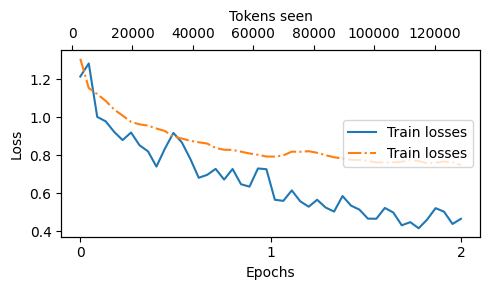

In [43]:
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt

def plot_losses(epochs_tensor, train_losses, val_losses, tokens_seen):
  fig, ax1 = plt.subplots(figsize=(5, 3))

  ax1.plot(epochs_tensor, train_losses, label='Train losses')
  ax1.plot(epochs_tensor, val_losses, label='Train losses', linestyle='-.')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Loss')
  ax1.legend(loc='center right')
  ax1.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=20)) # No decimal values on x axis

  ax2 = ax1.twiny()
  ax2.plot(tokens_seen, train_losses, label='Train losses', alpha=0)
  ax2.set_xlabel('Tokens seen')

  fig.tight_layout()
  plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, train_losses, val_losses, tokens_seen)

In [44]:
# Testing on test data

def generate_sample(start_context, tokenizer, model, max_tokens=50):
  model.eval()

  input_batch = text_to_token_ids(start_context, tokenizer)
  context_length = model.pos_embedding.weight.shape[0]

  generated_token_ids = generate_text_simple(
      input_batch,
      model,
      context_length,
      device,
      max_tokens
  )

  model.train()

  return token_ids_to_text(generated_token_ids, tokenizer)

for entry in test_data[:3]:
  input_text = data_alpaca_format(entry, with_response=False)
  resp = generate_sample(input_text, tokenizer, model)

  resp_text = resp[len(input_text):].replace("### Response:","").strip()
  print("=======Input:========\n", input_text)
  print("=======Correct Response:========\n", entry['output'])
  print("=========All model response:=========\n", resp)
  print("==========Model Response:=======\n", resp_text)
  print("============")

=======Input:========
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.
=======Correct Response:========
 The car is as fast as lightning.
=========All model response:=========
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

### Response:
The car is as fast as a bullet.
==========Model Response:=======
 The car is as fast as a bullet.
=======Input:========
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?
=======Correct Response:========
 The type of cloud typically associated with thunderstorms is cumulonimbus.
=========All model response:=========
 Below is a

In [45]:
# Generating responses

from tqdm import tqdm

def save_model_responses(test_data):
  for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = data_alpaca_format(entry, with_response=False)
    resp = generate_sample(input_text, tokenizer, model)
    resp_text = resp[len(input_text):].replace("### Response:","").strip()
    test_data[i]["model_response"] = resp_text

  with open("instruction_model_responses_with_lora.json", "w") as f:
    json.dump(test_data, f, indent=4)

save_model_responses(test_data)

100%|██████████| 110/110 [01:09<00:00,  1.59it/s]


In [46]:
from google.colab import files
files.download('instruction_model_responses_with_lora.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# To just save the LoRA weights
def get_lora_params(model):
  return {
      name: param for name, param in model.named_parameters()
  }

In [47]:
for k in model.state_dict():
  print(k)

token_embedding.weight
pos_embedding.weight
layer_norm.scale
layer_norm.shift
transformer_blocks.0.attn_block.mask
transformer_blocks.0.attn_block.W_query.linear.weight
transformer_blocks.0.attn_block.W_query.linear.bias
transformer_blocks.0.attn_block.W_query.lora.A
transformer_blocks.0.attn_block.W_query.lora.B
transformer_blocks.0.attn_block.W_key.linear.weight
transformer_blocks.0.attn_block.W_key.linear.bias
transformer_blocks.0.attn_block.W_key.lora.A
transformer_blocks.0.attn_block.W_key.lora.B
transformer_blocks.0.attn_block.W_value.linear.weight
transformer_blocks.0.attn_block.W_value.linear.bias
transformer_blocks.0.attn_block.W_value.lora.A
transformer_blocks.0.attn_block.W_value.lora.B
transformer_blocks.0.attn_block.projection.linear.weight
transformer_blocks.0.attn_block.projection.linear.bias
transformer_blocks.0.attn_block.projection.lora.A
transformer_blocks.0.attn_block.projection.lora.B
transformer_blocks.0.ffwd.layers.0.linear.weight
transformer_blocks.0.ffwd.layers

In [48]:
def save_lora_weights(model, path):
    lora_state_dict = {
        k: v.cpu()
        for k, v in model.state_dict().items()
        if "lora." in k
    }
    torch.save(lora_state_dict, path)

save_lora_weights(model, "lora_weights.pth")

In [50]:
!ls -ltrh lora_weights.pth # 14MB

-rw-r--r-- 1 root root 14M Apr 28 16:55 lora_weights.pth


In [51]:
torch.save(model.state_dict(), "entire_model.pth")

In [52]:
!ls -ltrh entire_model.pth # 684MB

-rw-r--r-- 1 root root 684M Apr 28 16:57 entire_model.pth


In [49]:
# Load LoRA weights
def load_lora_weights(model, path, device="cpu"):
    lora_state_dict = torch.load(path, map_location=device)
    model.load_state_dict(lora_state_dict, strict=False) #strict=False is important → ignores missing base weights

load_lora_weights(model, "lora_weights.pth")